In [1]:
import os
os.chdir("..")

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


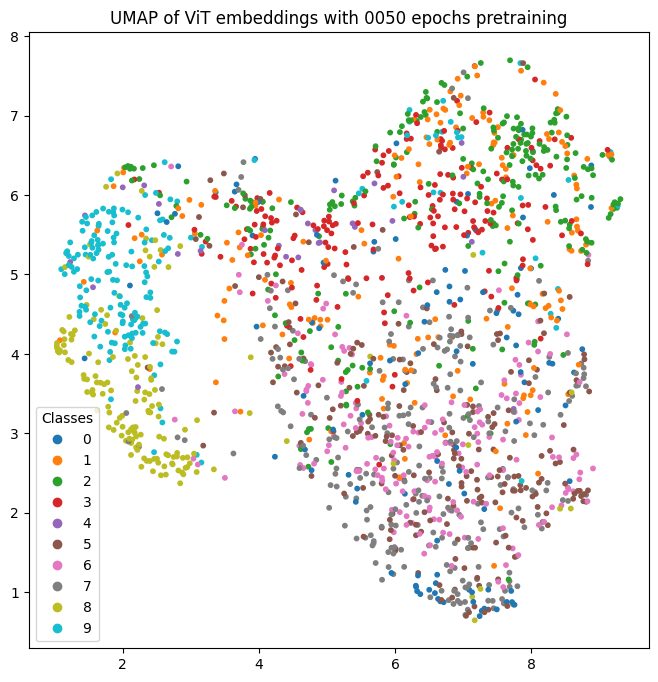

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


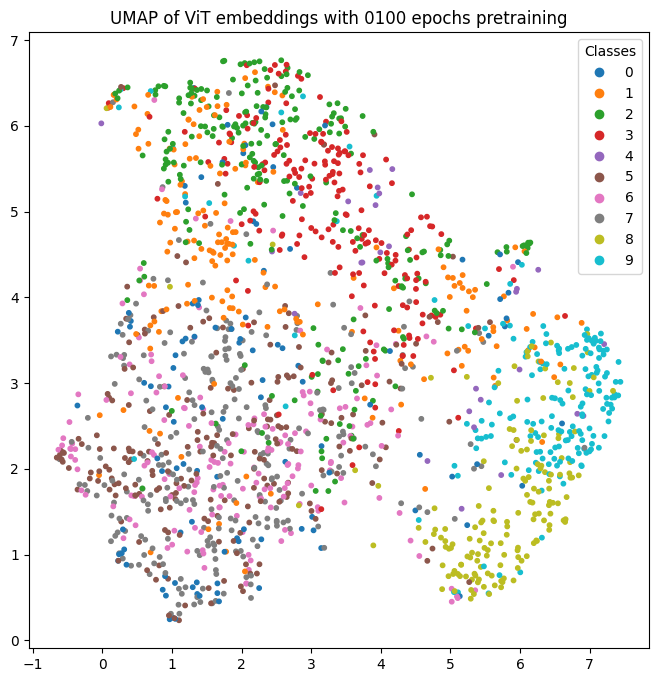

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


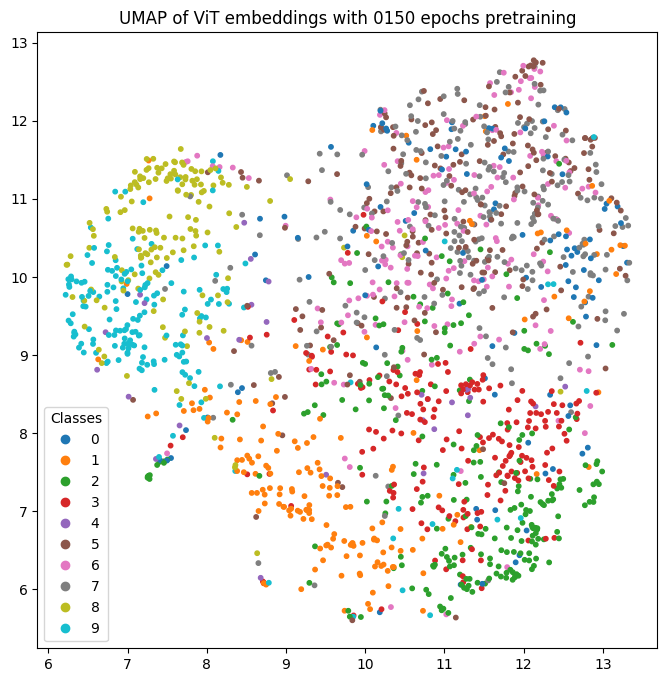

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


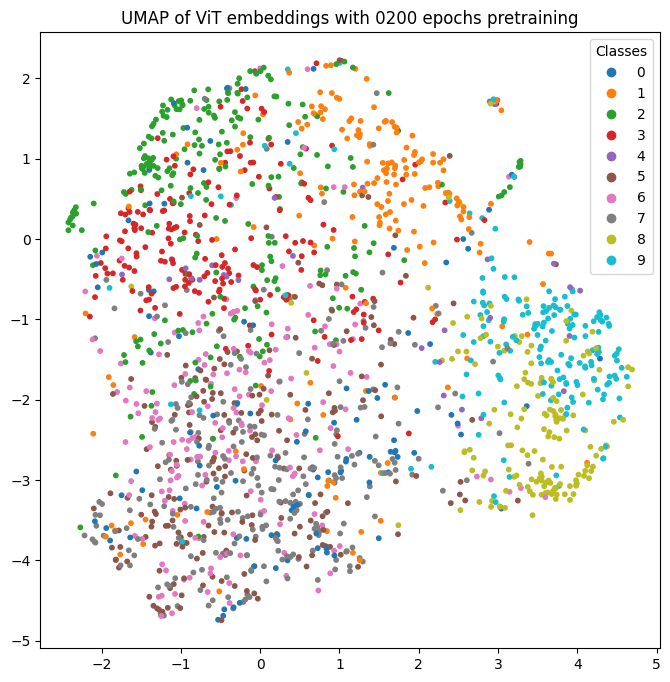

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


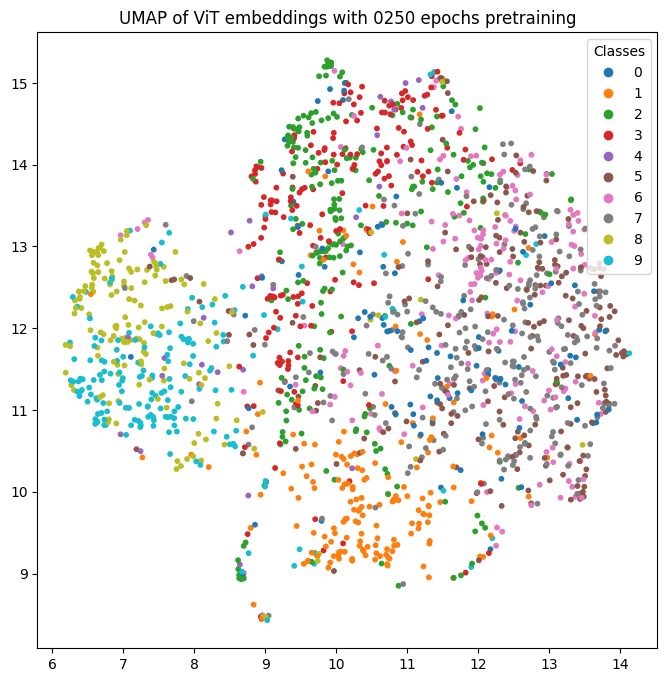

/home/liue/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


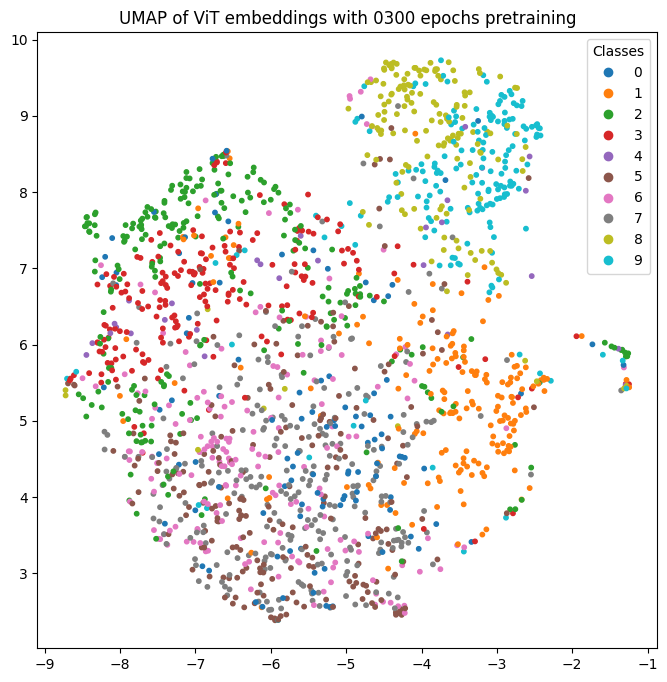

In [2]:
from scripts.lp_script import construct_backbone
from data.data import get_ssl_test_dataloader
import torch
import yaml
    
import umap
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("./configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

out_dir = (
        f"./checkpoints/checkpoints_{config['arch']}_"
        f"{config['ssl_batch_size']}_"
        f"{config['ssl_lr']}_"
        f"{config['ssl_wd']}_"
        f"{config['ssl_epochs']}_"
        f"{config['ssl_da_method']}"
    )

for i in ["0050", "0100", "0150", "0200", "0250", "0300"]:
    ckpt_path = f"{out_dir}/checkpoint_{i}.pth.tar"
    backbone = construct_backbone(
    arch=config["arch"],
    ckpt_path=ckpt_path,
    moco_t=config["moco_t"],
    moco_dim=config["moco_dim"],
    moco_mlp_dim=config["moco_mlp_dim"],
    device=device,
    )
    
    backbone.eval()
    
    test_loader = get_ssl_test_dataloader(batch_size=config["lp_batch_size"], 
                                          workers=config["workers"],
                                          normalization=config["ssl_normalization"])
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            emb = backbone(imgs.to(device))
            features.append(emb.cpu())
            labels.append(lbls)
            
    features = torch.cat(features).numpy()
    labels = torch.cat(labels).numpy()

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=2952)
    embedding_2d = reducer.fit_transform(features)

    plt.figure(figsize=(8,8))
    scatter = plt.scatter(embedding_2d[:,0], embedding_2d[:,1], c=labels, cmap="tab10", s=10)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(f"UMAP of ViT embeddings with {i} epochs pretraining")
    plt.show()